<a href="https://colab.research.google.com/github/agataben/bitenet/blob/main/Example%20-%20preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive
!unzip -q images.zip -d /content/

/content/drive/MyDrive


In [3]:
!rm '/content/images/caprese_salad/1987239 (1).jpg'

In [4]:
my_os = 'macOS'
if  my_os == 'macOS':
  %cd /content
  !rm -r __MACOSX

/content


In [5]:
from os import path

%cd /content
!git clone https://github.com/agataben/bitenet.git
%cd bitenet
!git checkout main

/content
Cloning into 'bitenet'...
remote: Enumerating objects: 41613, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 41613 (delta 115), reused 110 (delta 108), pack-reused 41487 (from 2)
Receiving objects: 100% (41613/41613), 1.86 GiB | 34.68 MiB/s, done.
Resolving deltas: 100% (355/355), done.
/content/bitenet
Already on 'main'
Your branch is up to date with 'origin/main'.


In [6]:
from src.utils import set_seed

seed = 1238
set_seed(seed)

In [7]:
from src.preprocessing import build_image_path_label_df
from src.utils import get_list_of_img_paths

data_root = '/content'
data_df = build_image_path_label_df(data_root = data_root)
len(data_df)

26999

In [8]:
import pandas as pd
from src.utils import make_class_to_idx_map

img_dir_path = '/content'
img_dir_name = 'images'
cvs_path = '/content'
class_to_indx_dict = make_class_to_idx_map(img_dir_path = img_dir_path, img_dir_name = img_dir_name, cvs_path = cvs_path)
pd.read_csv('/content/classes.csv')

,Unnamed: 0,class,index
0,0,apple_pie,0
1,1,baklava,1
2,2,beef_carpaccio,2
3,3,beet_salad,3
4,4,beignets,4
5,5,bruschetta,5
6,6,caesar_salad,6
7,7,cannoli,7
8,8,caprese_salad,8
9,9,carrot_cake,9


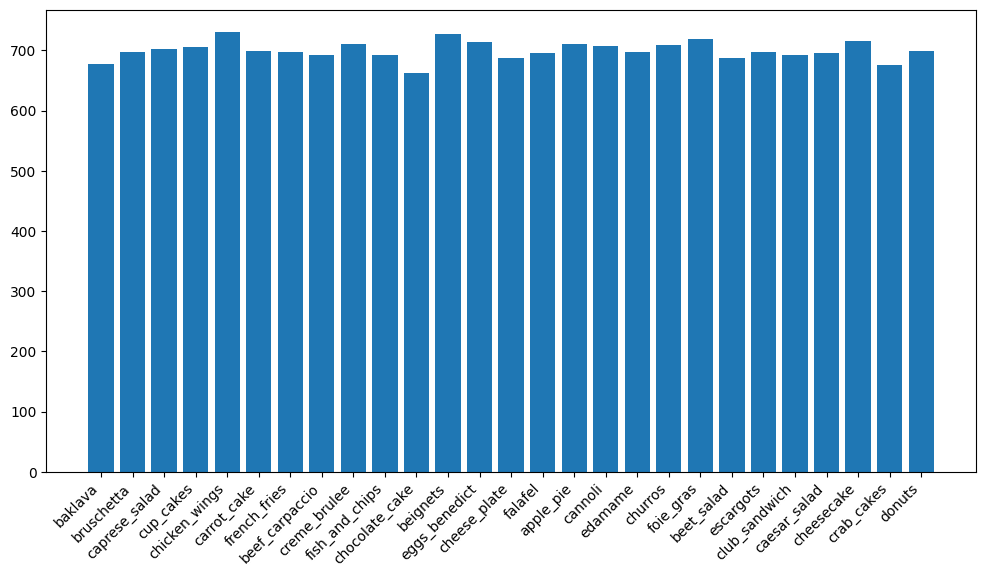

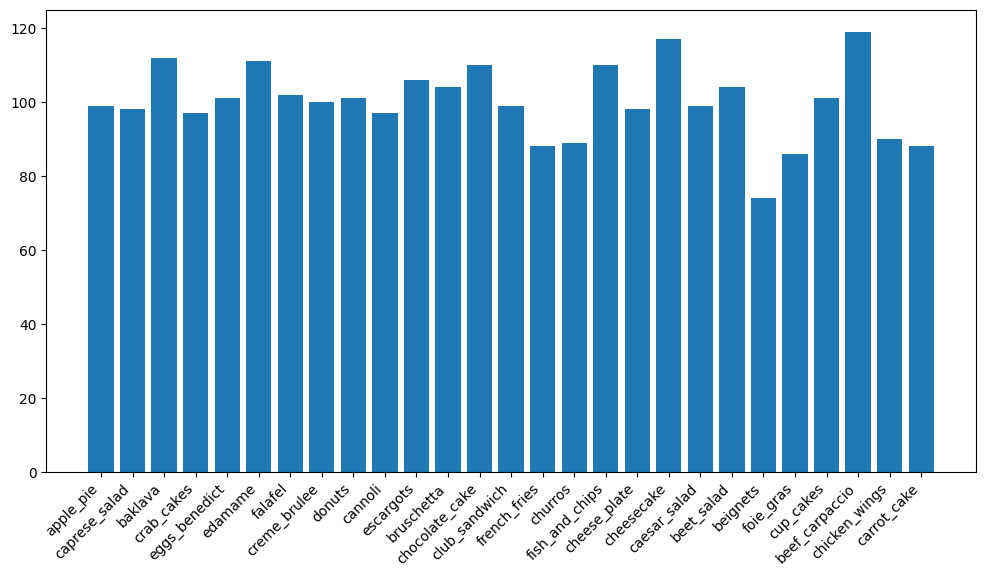

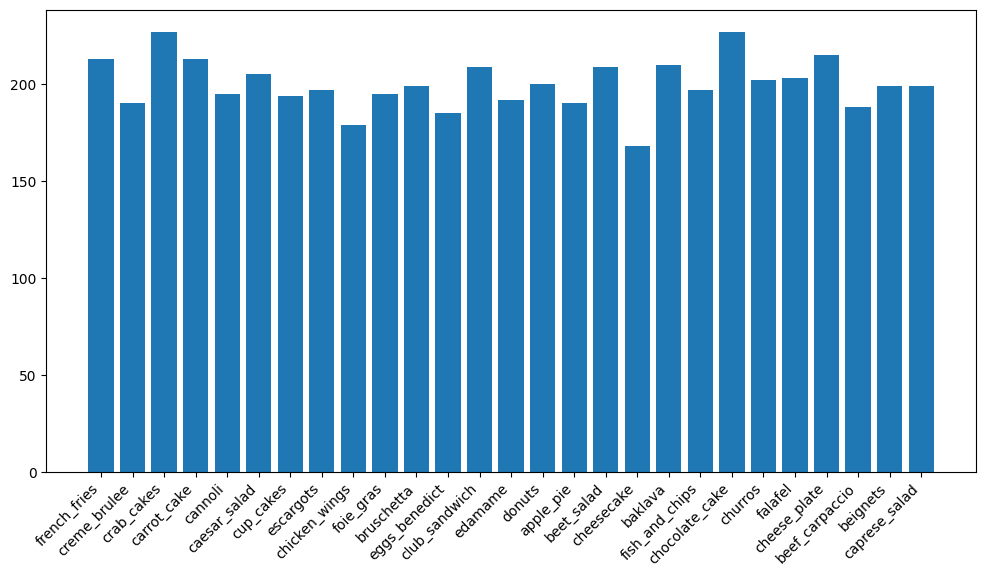

In [9]:
from src.preprocessing import split_dataset
from src.utils import plot_dataset_composition

csv_path = '/content'
train_df, val_df, test_df = split_dataset(data_df, train_size = 0.7, test_size = 0.2,
                                           val_size = 0.1, csv_path = csv_path)

plot_dataset_composition('/content/train.csv')
plot_dataset_composition('/content/val.csv')
plot_dataset_composition('/content/test.csv')

In [10]:
from src.utils import calculate_mean_and_std

csv_path = '/content/train.csv'
data_root = '/content'
yaml_path = '/content'
mean, std = calculate_mean_and_std(csv_path = csv_path, data_root = data_root, yaml_path = yaml_path)
print(mean)
print(std)

tensor([0.5432, 0.4492, 0.3548])
tensor([0.2714, 0.2768, 0.2827])


In [12]:
import os
from os import path

data_dir_path = '/content/drive/MyDrive/data'
if  not os.path.exists(data_dir_path):
  !mkdir {data_dir_path}

!cp /content/train.csv {os.path.join(data_dir_path, 'train.csv')}
!cp /content/test.csv {os.path.join(data_dir_path, 'test.csv')}
!cp /content/val.csv {os.path.join(data_dir_path, 'val.csv')}
!cp /content/normalizzation.yaml {os.path.join(data_dir_path, 'normalizzation.yaml')}
!cp /content/classes.csv {os.path.join(data_dir_path, 'classes.csv')}